# 示例策略1: 双均线择时策略

本策略根据交易目标的其日K线数据建立简单移动平均线的双均线交易模型，
交易策略如下：

策略包含两个参数：短周期天数S、长周期天数L
分别以两个不同的周期计算交易标的日K线收盘价的移动平均线，得到两根移动均线，以S为周期计算的均线为快均线，以L为周期计算的均线为慢均线，根据快慢均线的交叉情况产生交易信号：
1. 当快均线由下向上穿越慢均线时全仓买入交易标的
2. 当快均线由上向下穿越短均线时平仓

**模拟回测交易：**

- 回测数据为:沪深300指数（000300.SH)
- 回测周期为2011年1月1日到2020年12月31日
- 生成交易结果图表

**策略参数优化：**

- 同样使用HS300指数，在2011年至2020年共十年的历史区间上搜索最佳策略参数
- 并在2020年至2022年的数据上进行验证
- 输出30组最佳参数的测试结果

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../..'))
# 导入qteasy模块
import qteasy as qt
print(f'qteasy version: {qt.__version__}, datasource: {qt.QT_DATA_SOURCE}')

qteasy version: 2.2.0, datasource: mysql://www.qteasy.cn@9306/ts_db


In [2]:
from qteasy import Parameter, StgData
from qteasy import RuleIterator
# 创建双均线交易策略类
class Cross_SMA_PS(RuleIterator):
    """自定义双均线择时策略策略，产生的信号类型为交易信号
        这个均线择时策略有两个参数：
            - FMA 快均线周期
            - SMA 慢均线周期
        策略跟踪上述两个周期产生的简单移动平均线，当两根均线发生交叉时
        直接产生交易信号。
    """
    def __init__(self, **kwargs):
        """
        初始化交易策略的参数信息和基本信息
        """
        super().__init__(
            pars=[Parameter((10, 100), name='fast', par_type='int', value=10),
                  Parameter((30, 180), name='slow', par_type='int', value=160)],
            # 策略只有长短周期两个参数, 均为整型变量
            name='CROSSLINE',  # 策略的名称
            description='快慢双均线择时策略',  # 策略的描述
            data_types=StgData('close', freq='d', asset_type='ANY', window_length=200),  # 策略基于收盘价计算均线，因此数据类型为'close', 历史数据窗口长度为200
            **kwargs,
        )

    def realize(self):
        """策略的具体实现代码：
         - f: fast, 短均线计算日期；
         - s: slow: 长均线计算日期;
        """
        from qteasy.tafuncs import sma
        # 获取传入的策略参数
        f, s = self.get_pars('fast', 'slow')
        # 获取历史数据日频收盘价，计算长短均线的当前值和昨天的值
        close = self.get_data('close_ANY_d')
        # 使用qt.sma计算简单移动平均价
        s_ma = sma(close, s)
        f_ma = sma(close, f)
        
        # 为了考察两条均线的交叉, 计算两根均线昨日和今日的值，以便判断
        s_today, s_last = s_ma[-1], s_ma[-2]
        f_today, f_last = f_ma[-1], f_ma[-2]
        
        # 根据观望模式在不同的点位产生交易信号
        # 在PS信号类型下，1表示全仓买入，-1表示卖出全部持有股份
        # 当快均线自下而上穿过上边界，发出全仓买入信号
        if (f_last <= s_last) and (f_today >= s_today):  
            return 1
        # 当快均线自上而下穿过上边界，发出全部卖出信号
        elif (f_last >= s_last) and (f_today <= s_today):  
            return -1
        else:  # 其余情况不产生任何信号
            return 0


|                                  |
|         BACKTEST REPORT          |
|                                  |
qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 177.8 ms
time consumption for operation back testing:  8 sec 543.3 ms
investment starts on      2011-01-04 15:00:00
ends on                   2026-03-17 15:00:00
Total looped periods:     15.2 years.
-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary
          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000300.SH    69       69    138   55.0%     -0.0%     45.0%  

Total operation fee:     ¥    3,389.92
total investment amount: ¥  100,000.00
final value:              ¥  141,070.12
Total return:                    41.07% 
Avg Yearly return:                2.29%
Skewness:                         -0.91
Kurtosis:                         13.84
Benchmark return:                46.96% 
Bench

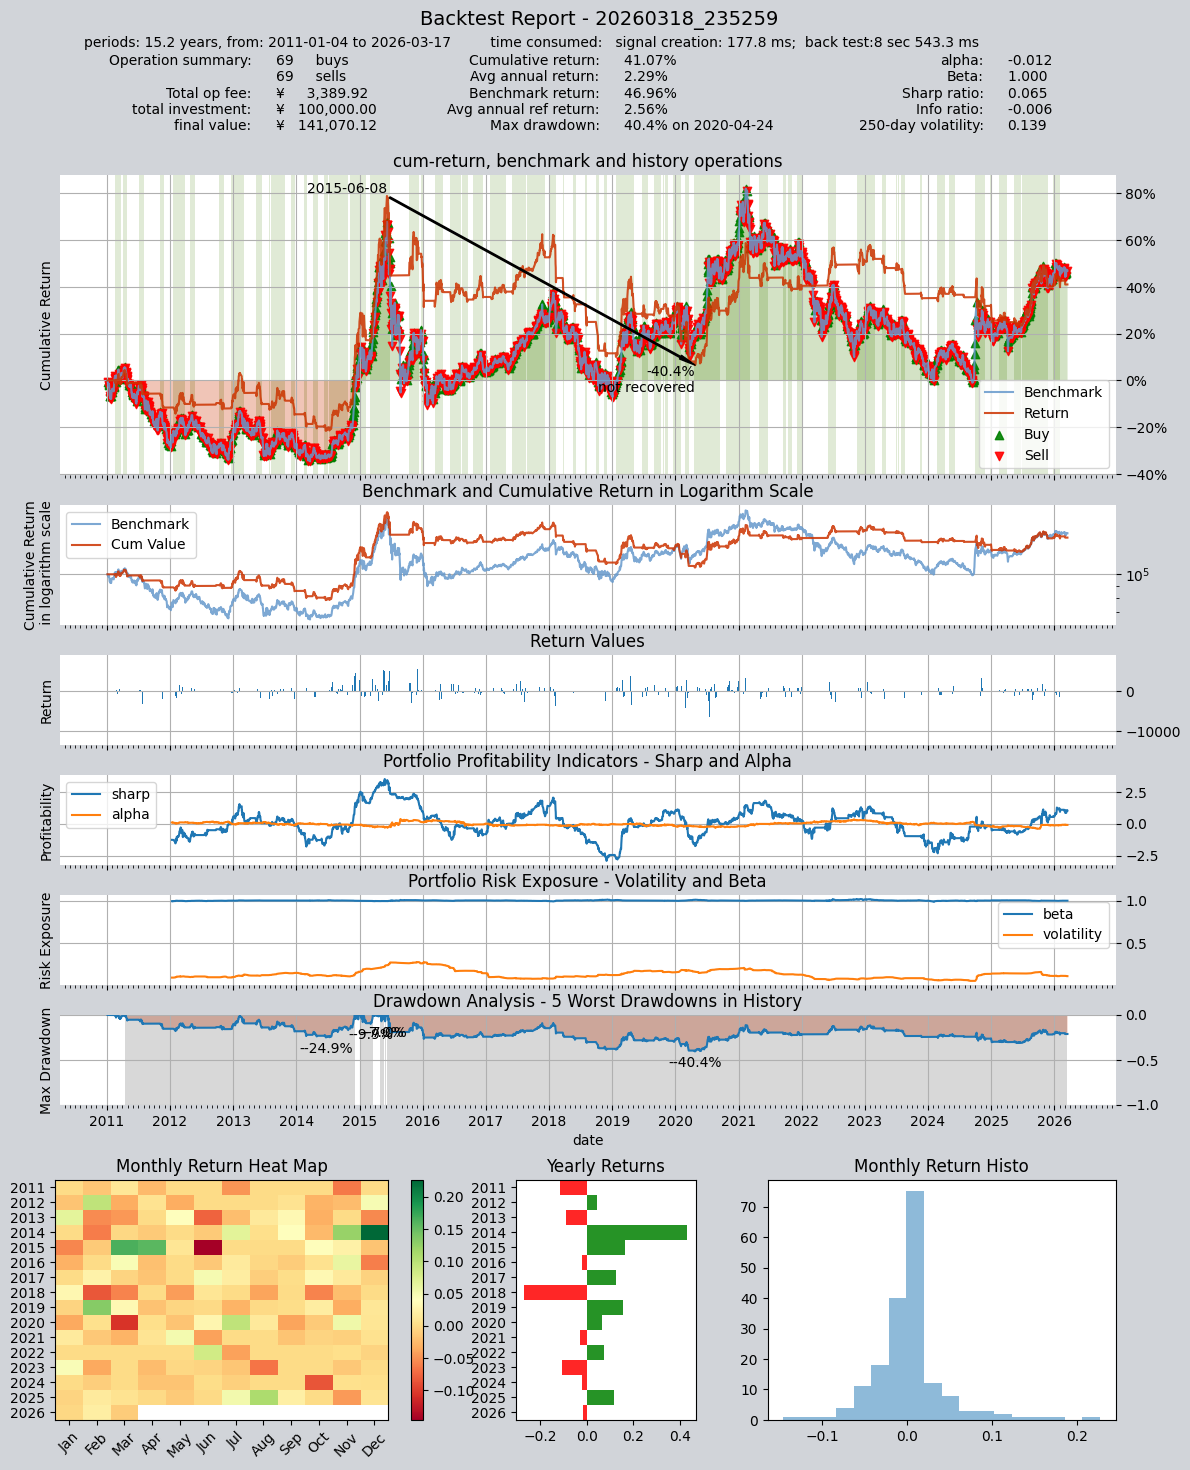

In [3]:
# 定义好策略后，定一个交易员对象，引用刚刚创建的策略，根据策略的规则
# 设定交易员的信号模式为PS
# PS表示比例交易信号，此模式下信号在-1到1之间，1表示全仓买入，-1表示
# 全部卖出，0表示不操作。
stg = Cross_SMA_PS()
op = qt.Operator([stg], signal_type='PS')

# 设置op的策略参数
op.set_parameter(0, par_values= (10, 30))  # 设置快慢均线周期分别为10天、16天
op.set_group_parameters('Group_1', blender_str='s0')
# 设置基本回测参数，开始运行模拟交易回测
res = qt.run(op, 
             mode=1,  # 运行模式为回测模式
             asset_pool='000300.SH',  # 投资标的为000300.SH即沪深300指数
             invest_start='20110101',  # 回测开始日期
             visual=True,  # 生成交易回测结果分析图
             trade_batch_size=0.01,
             sell_batch_size=0.01,
            )

Preparing optimization data from 2011-01-01 to 2020-01-01...


Epoch:1/1->392716.529: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:08<00:00,  3.59it/s]


Optimization finished, best parameters:


|                                  |
|       OPTIMIZATION REPORT        |
|                                  |
qteasy running mode: 2 - Strategy Parameter Optimization
time consumption for optimization: 1 min 201.7 ms
time consumption for evaluation:   8 sec 354.4 ms
investment starts on 2011-01-04 15:00:00
ends on 2019-12-31 15:00:00
Total looped periods: 9.0 years.
total investment amount: ¥   100,000.00
Benchmark type is 000300.SH
Total Benchmark rtn: 28.43% 
Average Yearly Benchmark rtn rate: 2.82%
Statistical analysis of optimal strategy messages indicators: 
Total return:        257.82% ± 15.48%
Annual return:       15.22% ± 0.54%
Alpha:               -0.132 ± 0.379
Beta:                0.187 ± 1.854
Sharp ratio:         0.371 ± 0.070
Info ratio:          0.009 ± 0.002
250 day volatility:  0.143 ± 0.007
Other messages indicators are listed in below table
   Strategy items Sell-outs Buy-ins ttl-fee      FV      ROI    MDD 
0      (57, 92) 

Epoch:1/1->253093.397: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:02<00:00, 13.27it/s]



|                                  |
|        VALIDATION REPORT         |
|                                  |
qteasy running mode: 2 - Strategy Parameter Optimization
time consumption for optimization: 1 min 201.7 ms
time consumption for evaluation:   8 sec 354.4 ms
investment starts on 2020-01-02 15:00:00
ends on 2021-12-31 15:00:00
Total looped periods: 2.0 years.
total investment amount: ¥   100,000.00
Benchmark type is 000300.SH
Total Benchmark rtn: 18.98% 
Average Yearly Benchmark rtn rate: 9.09%
Statistical analysis of optimal strategy messages indicators: 
Total return:        121.16% ± 20.04%
Annual return:       48.65% ± 6.79%
Alpha:               -0.066 ± 0.046
Beta:                0.999 ± 0.000
Sharp ratio:         0.607 ± 0.216
Info ratio:          -0.024 ± 0.024
250 day volatility:  0.175 ± 0.005
Other messages indicators are listed in below table
   Strategy items Sell-outs Buy-ins ttl-fee     FV      ROI    MDD 
0      (57, 92)       2.0      3.0   251.79 238,036.45 13

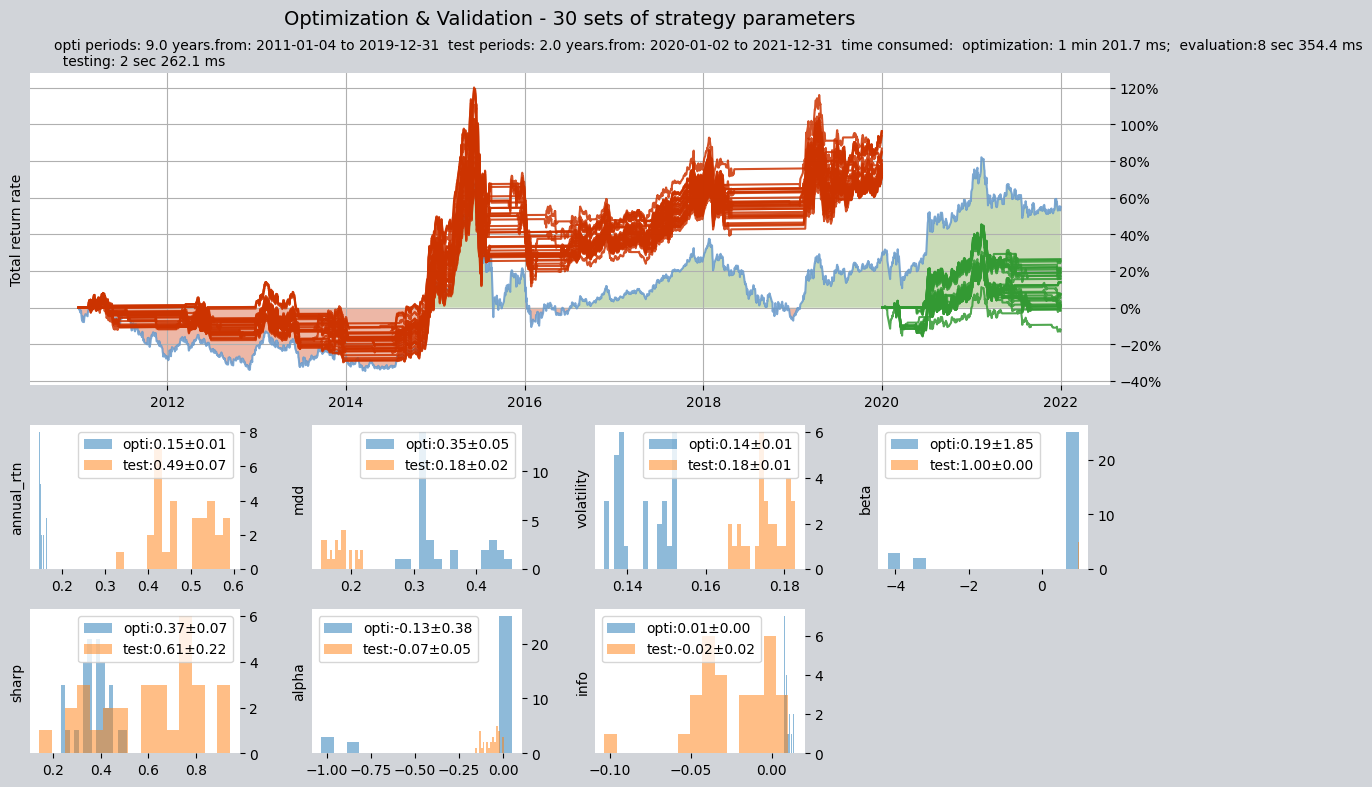

In [4]:
# 策略参数的优化
# 
# 设置op的策略参数
op.set_parameter(0, 
                 opt_tag=1  # 将op中的策略设置为可优化，如果不这样设置，将无法优化策略参数
                )
res = qt.run(op, 
             mode=2, 
             opti_start='20110101',  # 优化区间开始日期
             opti_end='20200101',  # 优化区间结束日期
             test_start='20200101',  # 独立测试开始日期
             test_end='20220101',  # 独立测试结束日期
             opti_sample_count=1000,  # 一共进行1000次搜索
             opti_method='SA',
             parallel=False,
            )

In [5]:
tstg = Cross_SMA_PS()
print(tstg)
tstg.par_values = (43, 144)
tstg.info()

Strategy RULE-ITER(CROSSLINE)


============================= Strategy: CROSSLINE ==============================

Strategy RULE-ITER(CROSSLINE)

Parameters: ['fast', 'slow'] = (43, 144)

Date Types: close_ANY_d x 200

----------------------------- Iteration Properties -----------------------------
Allow multi pars        True
Multi-parameter not set


|                                  |
|         BACKTEST REPORT          |
|                                  |
qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 180.3 ms
time consumption for operation back testing:  21.3 ms
investment starts on      2011-01-04 15:00:00
ends on                   2026-03-18 15:00:00
Total looped periods:     15.2 years.
-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary
          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000300.SH    11       12     23   69.8%     -0.0%     30.2%  

Total operation fee:     ¥      690.06
total investment amount: ¥  100,000.00
final value:              ¥  197,875.64
Total return:                    97.88% 
Avg Yearly return:                4.59%
Skewness:                         -0.97
Kurtosis:                         15.92
Benchmark return:                46.96% 
Benchmark Ye

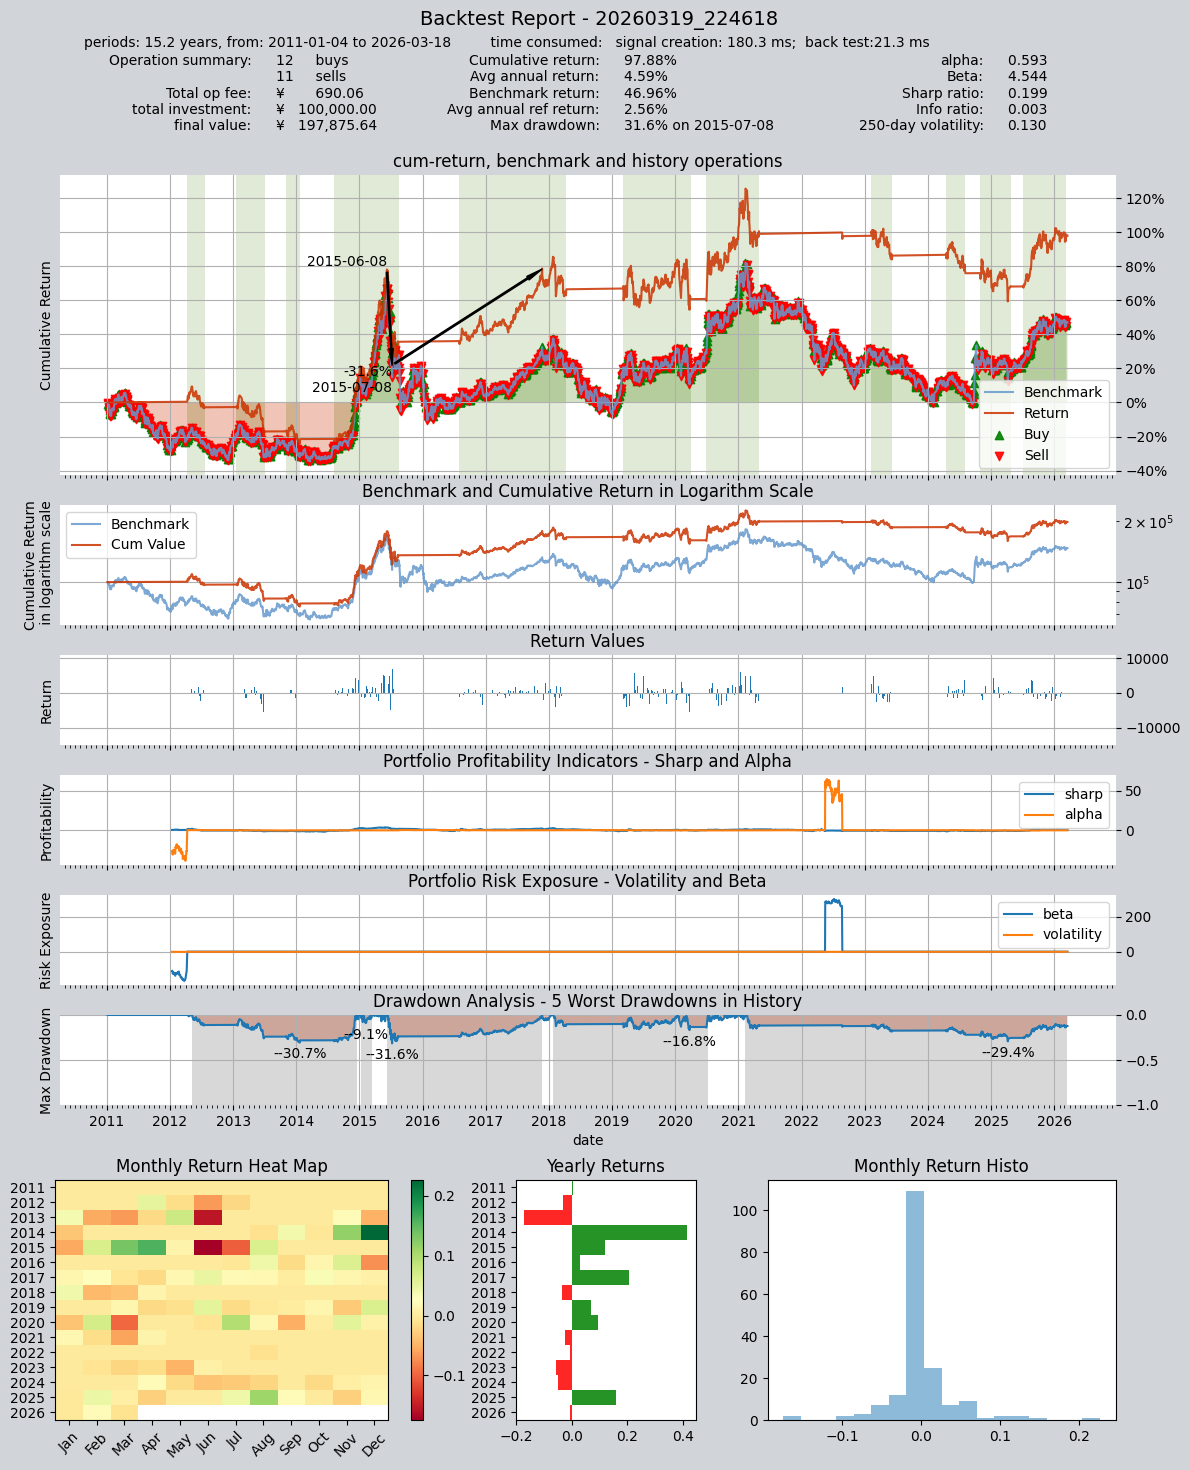

In [6]:
# 从优化结果中取出一组参数试验一下：
op.set_parameter(0, 
                 par_values= (43, 144)  # 修改策略参数，改为短周期25天，长周期166天
                )

# 重复一次测试，除策略参数以外，其他设置不变
res = qt.run(op, 
             mode=1,  
             asset_pool='000300.SH',  
             invest_start='20110101',  
             visual=True  
            )